In [76]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [77]:
'''Load the two IPL datasets (matches.csv and deliveries.csv) and display the first few rows of each.'''

matches_df = pd.read_csv('matches.csv')
deliveries_df = pd.read_csv('deliveries.csv')

print(matches_df)
print(deliveries_df)

      id  season       city        date                        team1  \
0      1    2017  Hyderabad  2017-04-05          Sunrisers Hyderabad   
1      2    2017       Pune  2017-04-06               Mumbai Indians   
2      3    2017     Rajkot  2017-04-07                Gujarat Lions   
3      4    2017     Indore  2017-04-08       Rising Pune Supergiant   
4      5    2017  Bangalore  2017-04-08  Royal Challengers Bangalore   
..   ...     ...        ...         ...                          ...   
631  632    2016     Raipur  2016-05-22             Delhi Daredevils   
632  633    2016  Bangalore  2016-05-24                Gujarat Lions   
633  634    2016      Delhi  2016-05-25          Sunrisers Hyderabad   
634  635    2016      Delhi  2016-05-27                Gujarat Lions   
635  636    2016  Bangalore  2016-05-29          Sunrisers Hyderabad   

                           team2                  toss_winner toss_decision  \
0    Royal Challengers Bangalore  Royal Challengers Bang

In [78]:
'''Check the structure of both datasets using .info() and .describe().'''

print(matches_df.shape)
print(matches_df.info())
print(matches_df.describe())

(636, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire

In [79]:
print(deliveries_df.shape)
print(deliveries_df.info())
print(deliveries_df.describe())

(150460, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 

In [80]:
#duplicates finding

print(matches_df.duplicated().value_counts())
print(deliveries_df.duplicated().value_counts())

False    636
Name: count, dtype: int64
False    150459
True          1
Name: count, dtype: int64


In [81]:
'''Identify and display the number of missing values in each column of both datasets.'''

matches_df.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [82]:
deliveries_df.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

In [83]:
#Drop the umpire3 column since it has all missing values.

matches_df.drop(['umpire3'], axis=1, inplace=True)

In [84]:
'''Fill missing values in player_dismissed, dismissal_kind, and fielder in the deliveries dataset.
Fill missing values in city, winner, player_of_match, umpire1, and umpire2 in the matches dataset.'''


matches_df['city'].fillna(value = 'unknown', inplace = True)
print(matches_df['city'].isnull().sum())

matches_df['winner'].fillna(value = 'unknown',inplace =True )
print(matches_df['winner'].isnull().sum())

matches_df['player_of_match'].fillna(value = 'unknown palyer',inplace =True )
print(matches_df['player_of_match'].isnull().sum())

matches_df['umpire1'].fillna(value = 'unknown umpire1',inplace =True )
print(matches_df['umpire1'].isnull().sum())

matches_df['umpire2'].fillna(value = 'unknown umpire2',inplace =True )
print(matches_df['umpire2'].isnull().sum())

deliveries_df['player_dismissed'].fillna(value ='unknown player',inplace =True)
print(deliveries_df['player_dismissed'].isnull().sum())

deliveries_df['dismissal_kind'].fillna(value ='unknown dismissal',inplace =True)
print(deliveries_df['dismissal_kind'].isnull().sum())


deliveries_df['fielder'].fillna(value ='unknown fielder',inplace =True)
print(deliveries_df['fielder'].isnull().sum())


0
0
0
0
0
0
0
0


C:\Users\SUDHI S R\AppData\Local\Temp\ipykernel_23312\1881519577.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches_df['city'].fillna(value = 'unknown', inplace = True)
C:\Users\SUDHI S R\AppData\Local\Temp\ipykernel_23312\1881519577.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

In [85]:
'''After preprocessing, display the datasets again to confirm that no missing values remain.'''

matches_df.isnull().sum()

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
dtype: int64

In [86]:
#dilivers value without null

deliveries_df.isnull().sum()


match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batsman             0
non_striker         0
bowler              0
is_super_over       0
wide_runs           0
bye_runs            0
legbye_runs         0
noball_runs         0
penalty_runs        0
batsman_runs        0
extra_runs          0
total_runs          0
player_dismissed    0
dismissal_kind      0
fielder             0
dtype: int64

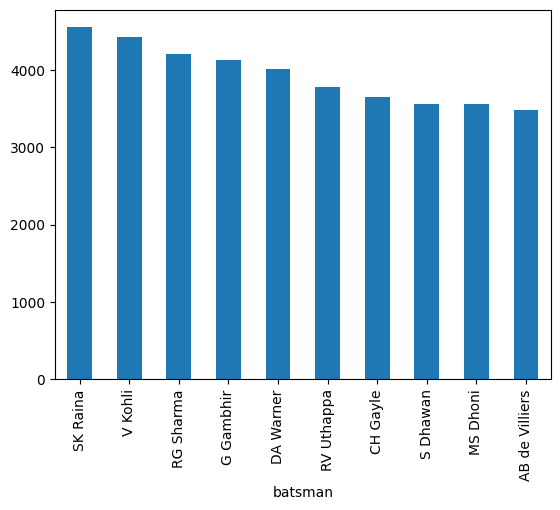

In [87]:
#Find the batsman who has scored the most runs in the history of IPL and visualize the top 10 run scorers using a bar chart.

s =deliveries_df.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)
s.plot(kind = 'bar')
plt.show()

In [88]:
s

batsman
SK Raina          4548
V Kohli           4423
RG Sharma         4207
G Gambhir         4132
DA Warner         4014
RV Uthappa        3778
CH Gayle          3651
S Dhawan          3561
MS Dhoni          3560
AB de Villiers    3486
Name: batsman_runs, dtype: int64

C:\Users\SUDHI S R\AppData\Local\Temp\ipykernel_23312\2747908044.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y =b.index,x = b.values,palette="cubehelix")


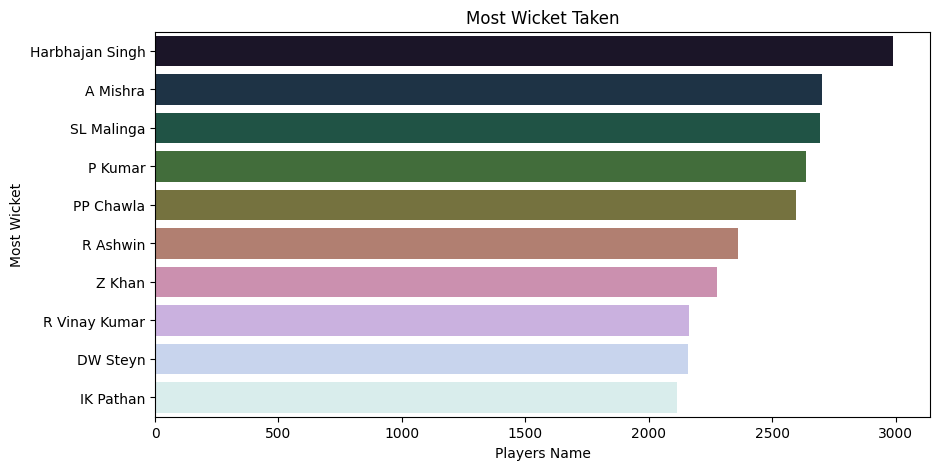

In [89]:
'''Find the bowler who has taken the most wickets in IPL and visualize the top 10 wicket takers.'''
wicket = deliveries_df[deliveries_df['dismissal_kind'] != 'Not Dismissed']
b =wicket.groupby('bowler')['player_dismissed'].count().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(y =b.index,x = b.values,palette="cubehelix")
plt.title("Most Wicket Taken")
plt.xlabel("Players Name")
plt.ylabel("Most Wicket")
plt.show()

In [90]:
b

bowler
Harbhajan Singh    2989
A Mishra           2703
SL Malinga         2694
P Kumar            2637
PP Chawla          2594
R Ashwin           2359
Z Khan             2276
R Vinay Kumar      2161
DW Steyn           2159
IK Pathan          2113
Name: player_dismissed, dtype: int64

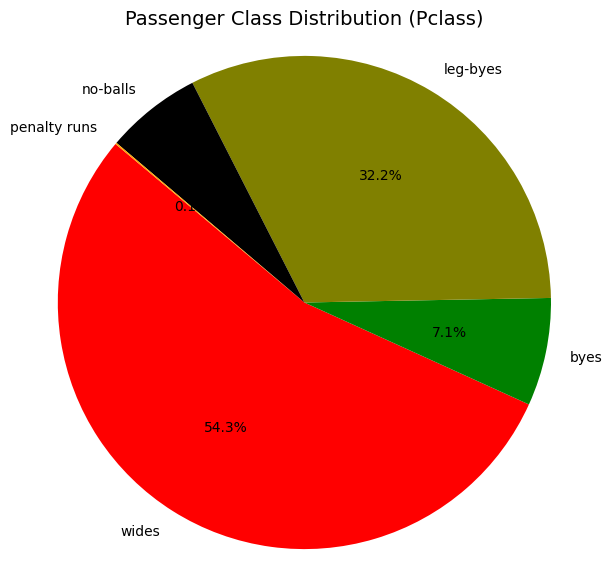

In [91]:
'''Analyze the distribution of extra runs (wides, byes, leg-byes, no-balls, penalty runs) and visualize it using a pie chart.'''

extra = deliveries_df[['wide_runs','bye_runs','legbye_runs','noball_runs','penalty_runs']].sum()


labels = ['wides', 'byes', 'leg-byes', 'no-balls', 'penalty runs']

plt.figure(figsize=(7, 7))
plt.pie(extra , labels=labels, autopct='%1.1f%%', startangle=140, colors=['red', 'green', 'olive','black','orange'])
plt.title('Passenger Class Distribution (Pclass)', fontsize=14)
plt.axis('equal') 
plt.show()

Number of IPL Seasons: 10

Matches Played in Each Season:
season
2008    58
2009    57
2010    60
2011    73
2012    74
2013    76
2014    60
2015    59
2016    60
2017    59
dtype: int64


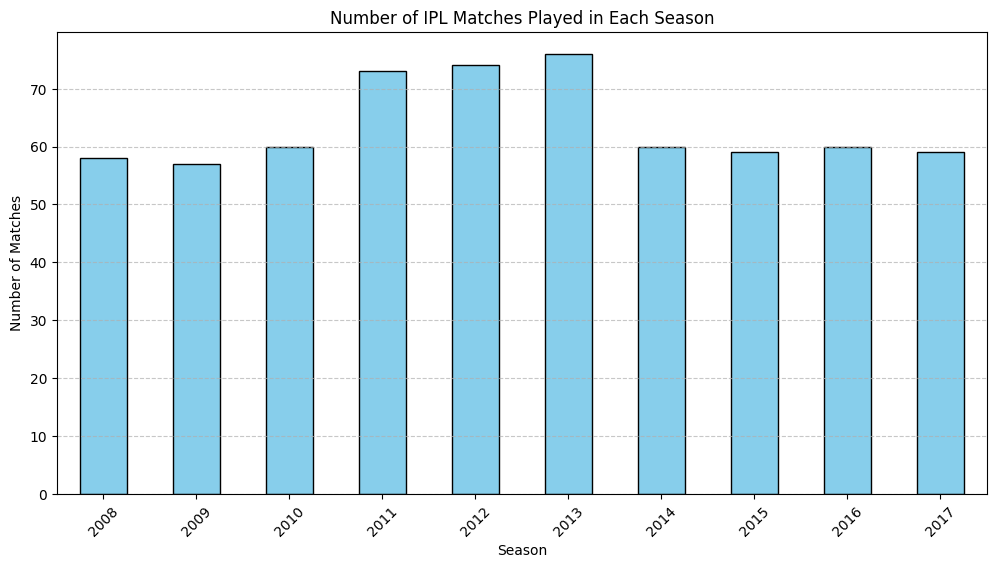

In [92]:
''' Display the number of IPL seasons played and the number of matches in each season. Visualize the matches per season using a bar chart.

matche'''

matches_per_season = matches_df.groupby("season").size()
print("Number of IPL Seasons:", matches_df["season"].nunique())
print("\nMatches Played in Each Season:")
print(matches_per_season)


plt.figure(figsize=(12,6))

matches_per_season.plot(kind="bar",color="skyblue",edgecolor="black")

plt.title("Number of IPL Matches Played in Each Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

C:\Users\SUDHI S R\AppData\Local\Temp\ipykernel_23312\488119871.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = top_winner.index,y = top_winner.values,palette="cubehelix")


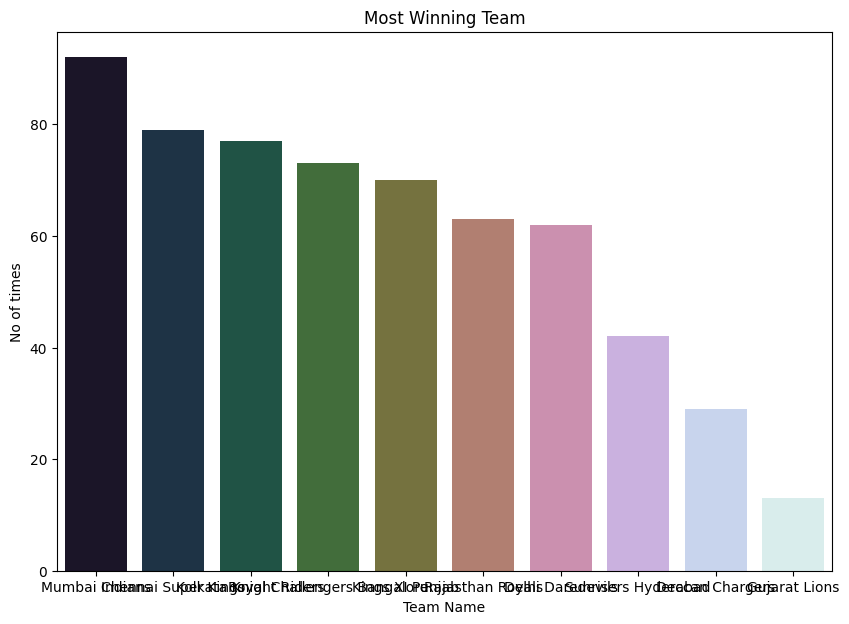

In [97]:
''' Identify the team with the most wins in IPL. Visualize the wins of the top 10 teams using a horizontal bar chart.'''


top_winner = matches_df['winner'].value_counts().head(10)
plt.figure(figsize =(10,7))
sns.barplot(x = top_winner.index,y = top_winner.values,palette="cubehelix")
plt.title("Most Winning Team")
plt.xlabel("Team Name")
plt.ylabel("No of times")
plt.show() 